In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine,fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             mean_squared_error, r2_score)
from sklearn.preprocessing import StandardScaler

## Modelos - Clasificación y Regresión

En esta clase exploraremos **modelos ensamblados** (Random Forest, Gradient Boosting), **redes neuronales** (MLP con sklearn) y **deep learning** (CNN con Keras/TensorFlow). Comenzamos repasando el Árbol de Decisión porque es la pieza fundamental sobre la cual se construyen los métodos ensamblados.

| Algoritmo         | Clasificación | Regresión |
|-------------------|---------------|-----------|
| Árbol de Decisión | DecisionTreeClassifier | DecisionTreeRegressor |
| Random Forest     | RandomForestClassifier | RandomForestRegressor |
| Gradient Boosting | GradientBoostingClassifier | GradientBoostingRegressor |
| Red Neuronal (MLP)| MLPClassifier | MLPRegressor |


# Clasificación 

### Dataset: Wine

El dataset Wine contiene el análisis químico de vinos cultivados en la misma región de Italia pero derivados de **3 variedades diferentes** de uva.

| Variable | Descripción |
|----------|-------------|
| alcohol | Contenido de alcohol |
| malic_acid | Ácido málico |
| ash | Ceniza |
| alcalinity_of_ash | Alcalinidad de la ceniza |
| magnesium | Magnesio |
| total_phenols | Fenoles totales |
| flavanoids | Flavonoides |
| nonflavanoid_phenols | Fenoles no flavonoides |
| proanthocyanins | Proantocianinas |
| color_intensity | Intensidad de color |
| hue | Tonalidad |
| od280/od315_of_diluted_wines | Relación OD280/OD315 |
| proline | Prolina |
| **target** | **Variedad de uva (0, 1, 2)** |

- **178 muestras** con 13 características químicas
- Problema de **clasificación multiclase** (3 clases)


In [2]:
# Cargar Wine dataset desde scikit-learn
# 13 características químicas de tres variedades de vino
# Documentación oficial: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html
wine = load_wine(as_frame=True)
df = wine.frame.copy()
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


Dimensiones: (178, 14)

Distribución de clases:
target
0    59
1    71
2    48
Name: count, dtype: int64

Estadísticas descriptivas:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89,0.94
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91,0.78
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00,0.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50,0.00
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50,1.00
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00,2.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00,2.00


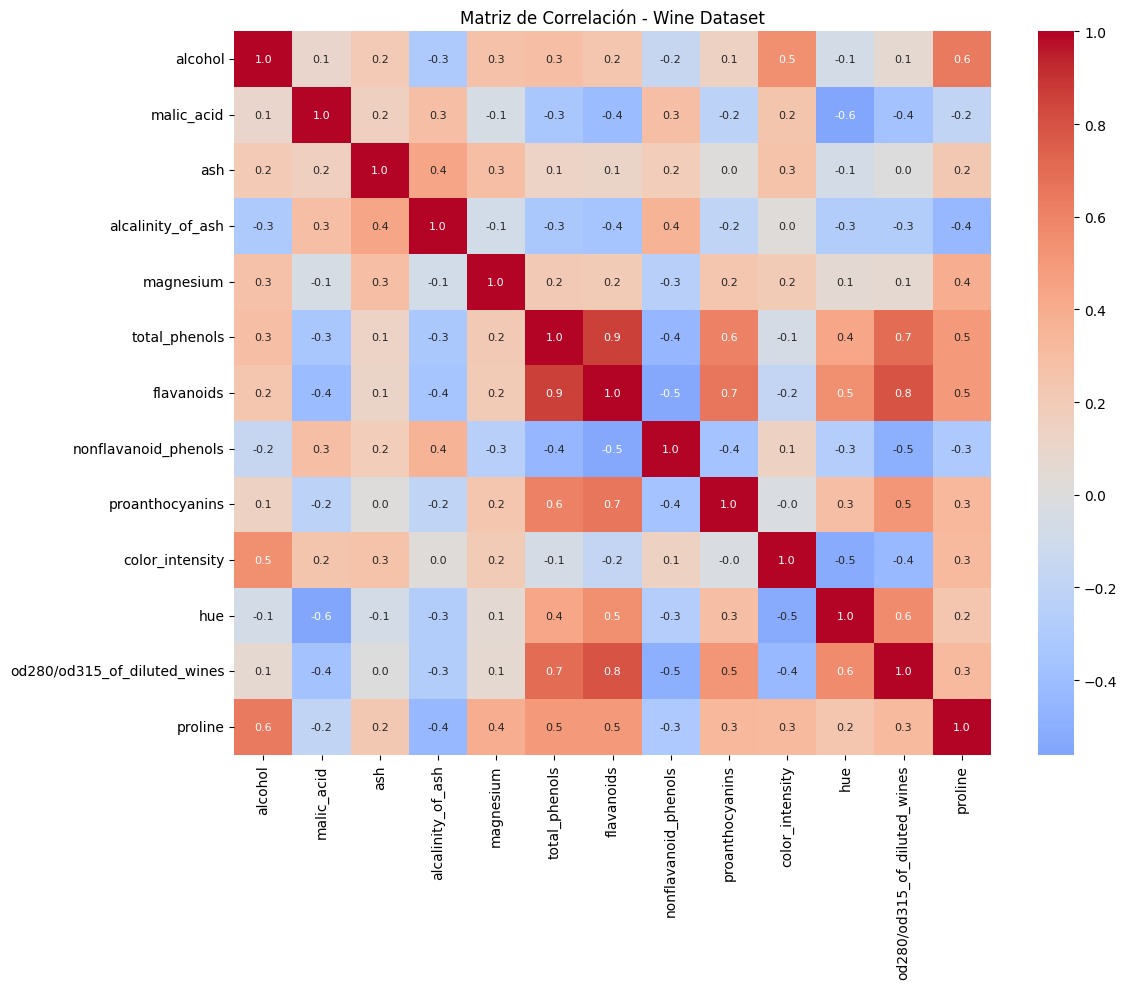

In [3]:
# Análisis exploratorio - Wine Dataset
print(f'Dimensiones: {df.shape}')
print(f'\nDistribución de clases:')
print(df['target'].value_counts().sort_index())
print(f'\nEstadísticas descriptivas:')
display(df.describe().round(2))

# Heatmap de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(df.drop(columns=['target']).corr(), annot=True, cmap='coolwarm', center=0, fmt='.1f', annot_kws={'size': 8})
plt.title('Matriz de Correlación - Wine Dataset')
plt.tight_layout()
plt.show()


In [4]:
# Variables predictoras (X) y objetivo (y)
X = df.drop(columns=['target'])
y = df['target']  # 0,1,2 representan variedades de vino distintas
class_names = wine.target_names
feature_names = X.columns

# Dividir datos en entrenamiento y prueba (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## DecisionTreeClassifier:

<img src="https://miro.medium.com/v2/resize:fit:2000/1*S10T4ah3_JqdQ-eY6Hau0Q.png" width="600" height="400">

- Árbol que particiona datos según características.
- Hiperparámetros clave:
  * max_depth: Profundidad máxima (evita overfitting).
  * min_samples_split: Mínimo de muestras para dividir un nodo.
  * min_samples_leaf: Mínimo de muestras en cada hoja.
  * criterion: 'gini' o 'entropy'. Mide impureza del nodo. Gini = 1 - Σ(p_i^2). Cuanto más bajo el valor de Gini, mayor pureza de los nodos tras el split.

- Poda pre-poda vía max_depth para no dejar hojas con un solo registro.

Documentación:
https://scikit-learn.org/stable/modules/tree.html#classification

In [5]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [6]:
y_pred_dt = dt.predict(X_test)
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.3f}")

Decision Tree Accuracy: 0.944


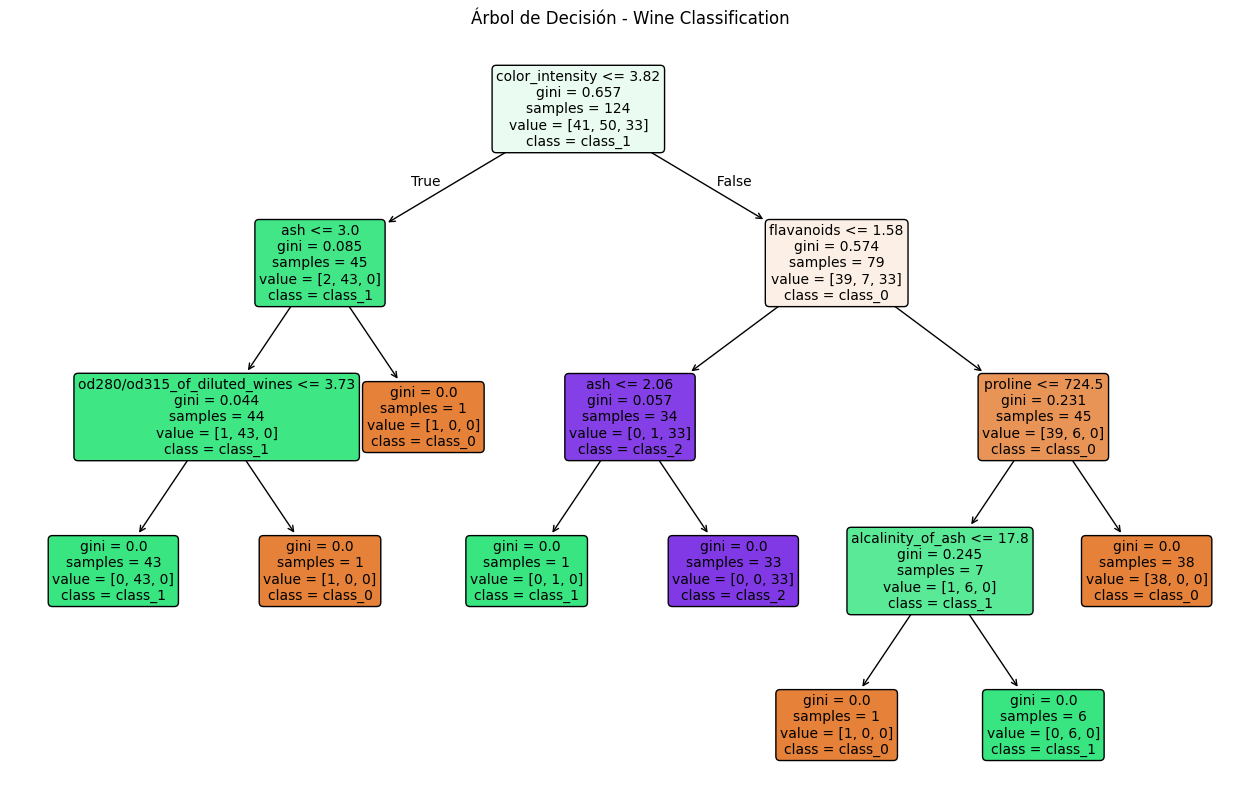

In [7]:
# Visualización del árbol entrenado
plt.figure(figsize=(16,10))
plot_tree(
    dt,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de Decisión - Wine Classification")
plt.show()

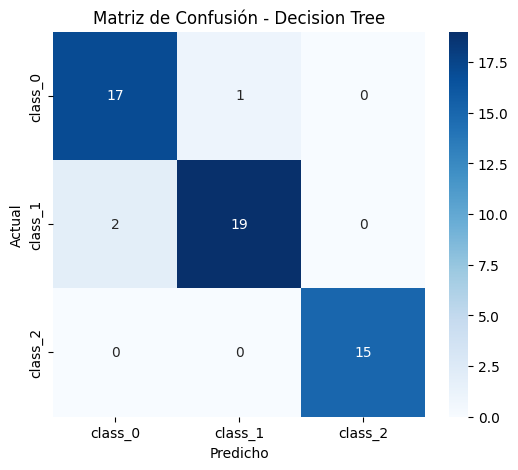

              precision    recall  f1-score   support

     class_0       0.89      0.94      0.92        18
     class_1       0.95      0.90      0.93        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.94        54
   macro avg       0.95      0.95      0.95        54
weighted avg       0.95      0.94      0.94        54



In [8]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_dt, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names
)
plt.title("Matriz de Confusión - Decision Tree")
plt.xlabel('Predicho')
plt.ylabel('Actual')
plt.show()
print(classification_report(y_test, y_pred_dt, target_names=class_names))

### Feature Importance (Importancia de Variables)

La importancia de variables nos dice **cuánto contribuye cada característica** a las predicciones del modelo. Esto es útil para:
- Entender **qué variables influyen más** en el resultado.
- Identificar variables irrelevantes que podrían eliminarse.
- Explicar el modelo a personas no técnicas.

**¿Cómo se calcula en árboles de decisión?**
Cada vez que una variable se usa para hacer un split en el árbol, se mide cuánto **reduce la impureza** (Gini o entropía) de los nodos resultantes. La importancia de una variable es la suma total de estas reducciones, normalizada para que todas sumen 1. En Random Forest y Gradient Boosting, se promedia esta importancia a través de todos los árboles del ensamble.


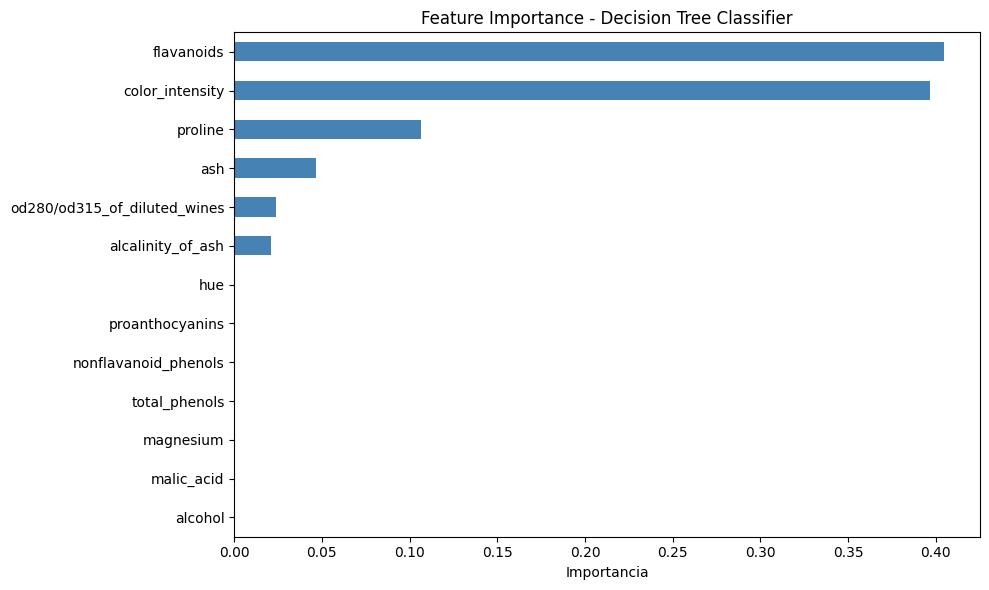

In [9]:
# Feature Importance - Decision Tree
fi_dt = pd.Series(dt.feature_importances_, index=feature_names).sort_values()
plt.figure(figsize=(10, 6))
fi_dt.plot(kind='barh', color='steelblue')
plt.title('Feature Importance - Decision Tree Classifier')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()


### Overfitting vs Underfitting

Antes de ver los modelos ensamblados, es importante entender por qué existen:

- **Overfitting (sobreajuste)**: El modelo memoriza los datos de entrenamiento, incluyendo el ruido. Tiene alta precisión en train pero baja en test.
  - Ejemplo: Un árbol de decisión sin límite de profundidad puede crear una hoja para cada dato.

- **Underfitting (subajuste)**: El modelo es demasiado simple para capturar los patrones. Baja precisión tanto en train como en test.
  - Ejemplo: Un árbol con `max_depth=1` (solo una decisión).

- **Cómo controlar el overfitting**:
  - En árboles: limitar `max_depth`, `min_samples_split`, `min_samples_leaf`
  - En ensembles: combinar múltiples modelos (Random Forest, Gradient Boosting)
  - En redes neuronales: regularización, early stopping, dropout

Los **modelos ensamblados** nacen precisamente para combatir el overfitting: al combinar múltiples modelos "débiles", se obtiene un modelo más robusto.


## RandomForestClassifier:

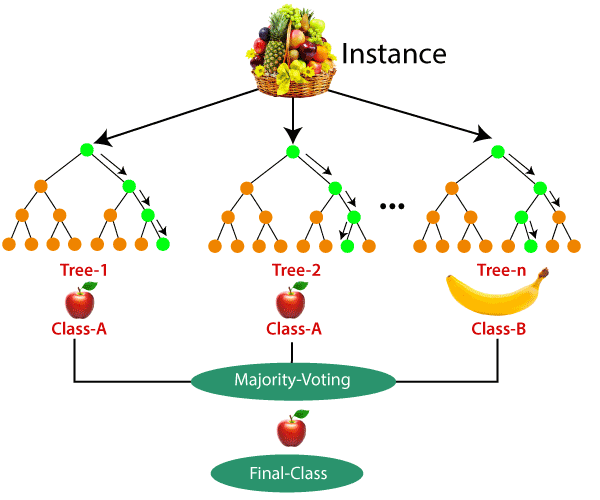

- Ensamble de árboles.
- Hiperparámetros clave:
  * n_estimators: Número de árboles.
  * max_features: Características en cada split.
  * max_depth: Profundidad de los árboles.

Documentación:
https://scikit-learn.org/stable/modules/ensemble.html#forest

In [10]:
rf = RandomForestClassifier(n_estimators=200, max_depth=7)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=7, n_estimators=200)

In [11]:
y_pred_rf = rf.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")

Random Forest Accuracy: 1.000


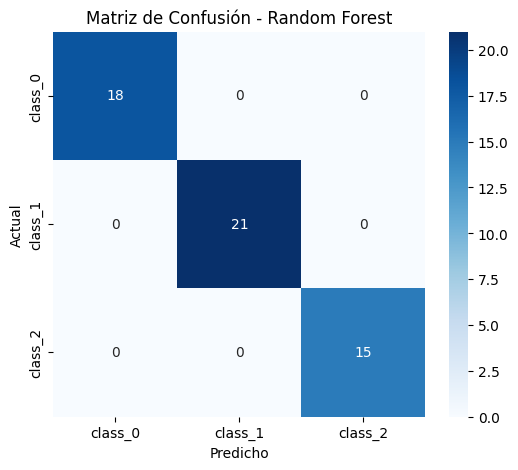

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



In [12]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_rf, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names
)
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel('Predicho')
plt.ylabel('Actual')
plt.show()
print(classification_report(y_test, y_pred_rf, target_names=class_names))

La importancia de variables en Random Forest es más **estable** que en un solo árbol de decisión, porque promedia la importancia a través de muchos árboles entrenados con diferentes subconjuntos de datos.


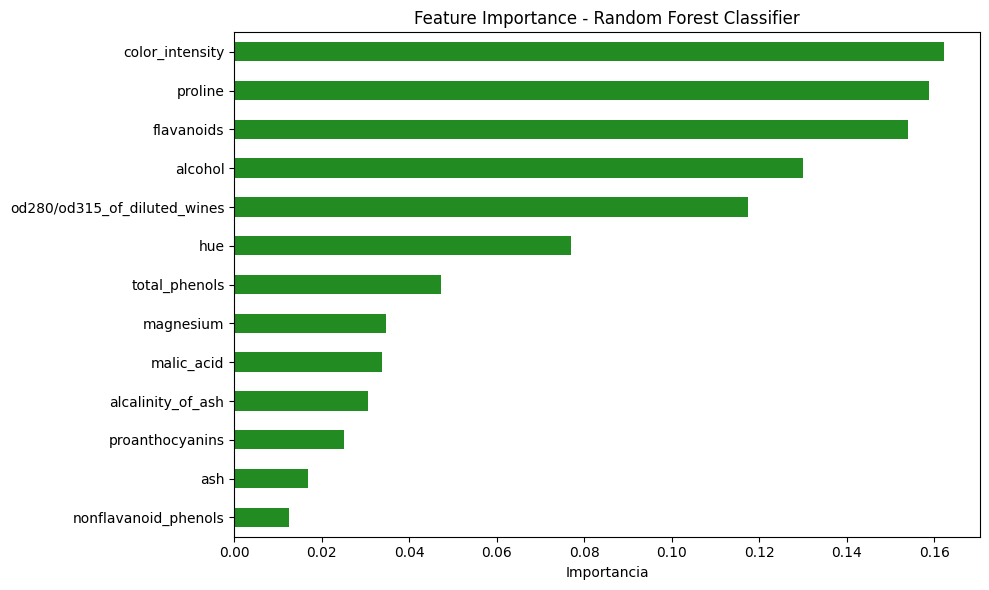

In [13]:
# Feature Importance - Random Forest
fi_rf = pd.Series(rf.feature_importances_, index=feature_names).sort_values()
plt.figure(figsize=(10, 6))
fi_rf.plot(kind='barh', color='forestgreen')
plt.title('Feature Importance - Random Forest Classifier')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()


## GradientBoostingClassifier:

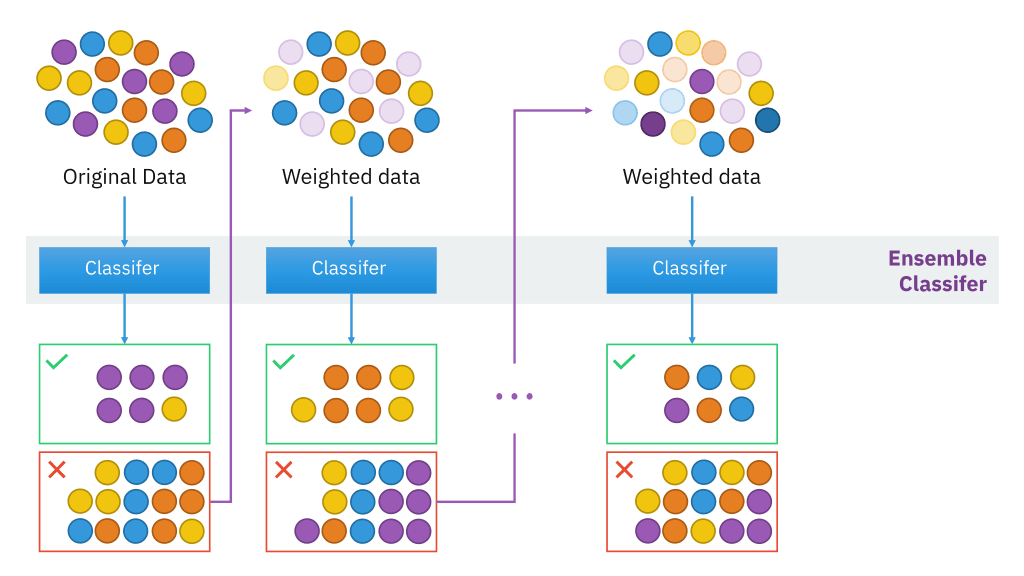

- Ensamble secuencial que corrige errores iterativamente.
- A diferencia de Random Forest (que entrena árboles en paralelo), Gradient Boosting entrena cada árbol nuevo para corregir los errores del anterior.
- Hiperparámetros:
  * learning_rate: peso de cada nuevo árbol (valores pequeños = aprendizaje más lento pero más preciso).
  * n_estimators: número de etapas (árboles secuenciales).
  * max_depth: profundidad de árboles base (usualmente más pequeña que en Random Forest).
- Preciso pero sensible a overfitting si no se controlan los hiperparámetros.

Documentación:
https://scikit-learn.org/stable/modules/ensemble.html#gradient-boosting


In [14]:
gb = GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=4, random_state=42)
gb.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, max_depth=4, n_estimators=150,
                           random_state=42)

In [15]:
y_pred_gb = gb.predict(X_test)
print(f"Gradient Boosting Accuracy: {accuracy_score(y_test, y_pred_gb):.3f}")

Gradient Boosting Accuracy: 0.907


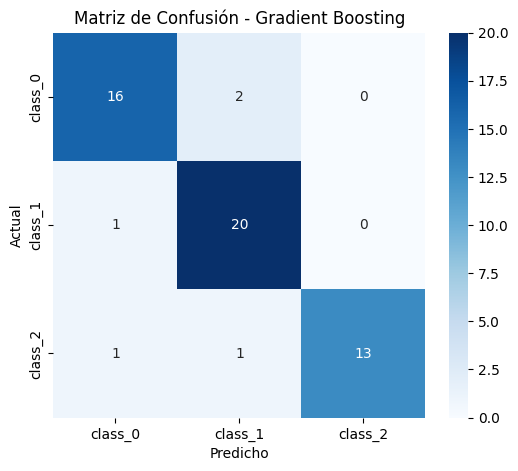

              precision    recall  f1-score   support

     class_0       0.89      0.89      0.89        18
     class_1       0.87      0.95      0.91        21
     class_2       1.00      0.87      0.93        15

    accuracy                           0.91        54
   macro avg       0.92      0.90      0.91        54
weighted avg       0.91      0.91      0.91        54



In [16]:
cm_gb = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_gb, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names
)
plt.title("Matriz de Confusión - Gradient Boosting")
plt.xlabel('Predicho')
plt.ylabel('Actual')
plt.show()
print(classification_report(y_test, y_pred_gb, target_names=class_names))

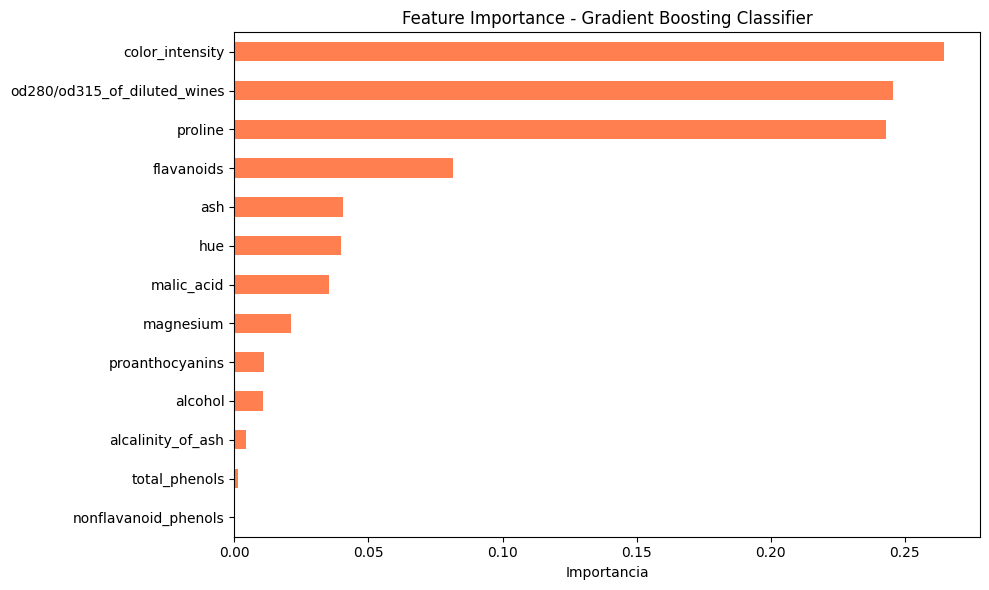

In [17]:
# Feature Importance - Gradient Boosting
fi_gb = pd.Series(gb.feature_importances_, index=feature_names).sort_values()
plt.figure(figsize=(10, 6))
fi_gb.plot(kind='barh', color='coral')
plt.title('Feature Importance - Gradient Boosting Classifier')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()


## Redes Neuronales ANN 

#### Inspiración Biológica
Las redes neuronales están inspiradas en el cerebro humano, donde las neuronas reciben señales, las procesan y las transmiten a otras neuronas. Las redes artificiales imitan este funcionamiento mediante nodos (neuronas) y conexiones (pesos).

#### Arquitectura de un Perceptrón Multicapa (MLP)

 - Capa de Entrada: Recibe las características del dato.

 - Capas Ocultas: 
    - Una o varias capas con n neuronas cada una.
    - Cada neurona calcula una combinación lineal de sus entradas y aplica una función de activación.

 - Capa de Salida
    - Para clasificación: neuronas igual al número de clases, con softmax.
    - Para regresión: una neurona (o más), con activación lineal.

    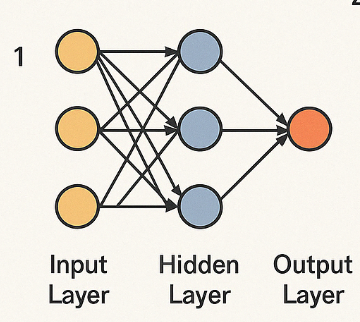

    Link de referencia de mas arquitecturas explicadas https://www.asimovinstitute.org/neural-network-zoo/

 - Arquitecturas especializadas muy usadas:
   - CNN   red neuronal convolucional
   - RNN  red neuronal recurrente
   - LSTM Long Short Term Memory

#### Función de Activación:
 - Step
 - Sigmoid
 - Tanh
 - ReLU
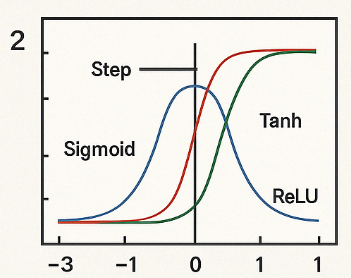

#### Hiperparametros:
 - hidden_layer_sizes: Tupla con neuronas por capa oculta.
 - activation: Función de activación (relu, tanh, logistic).
 - solver: Optimizador (adam, sgd, lbfgs).
 - learning_rate_init: Tasa de aprendizaje inicial.
 - max_iter: Número de iteraciones de entrenamiento.


#### Loss:
(o función de pérdida) en redes neuronales es una métrica que mide qué tan bien o mal el modelo está realizando sus predicciones en comparación con los valores reales. Es una función matemática que cuantifica el error entre las predicciones del modelo y las etiquetas verdaderas.

#### ¿Qué hace una función de activación?

Cada neurona calcula una suma ponderada de sus entradas: `z = w1*x1 + w2*x2 + ... + b`. Sin una función de activación, la red sería una simple combinación lineal (sin importar cuántas capas tenga). La función de activación introduce **no linealidad**, permitiendo que la red aprenda patrones complejos.

| Función | Fórmula | Rango | Cuándo usarla |
|---------|---------|-------|---------------|
| **Step** | 1 si z > 0, sino 0 | {0, 1} | Histórica (perceptrón original). No se usa en redes modernas porque no es diferenciable. |
| **Sigmoid** | 1 / (1 + e^(-z)) | (0, 1) | Capa de salida en clasificación binaria. Convierte cualquier valor en una probabilidad. |
| **Tanh** | (e^z - e^(-z)) / (e^z + e^(-z)) | (-1, 1) | Capas ocultas cuando se necesitan valores negativos. Centrada en 0 (mejor que sigmoid para capas ocultas). |
| **ReLU** | max(0, z) | [0, ∞) | La más usada en capas ocultas. Simple, rápida, y funciona muy bien en la práctica. "Apaga" neuronas con valores negativos. |


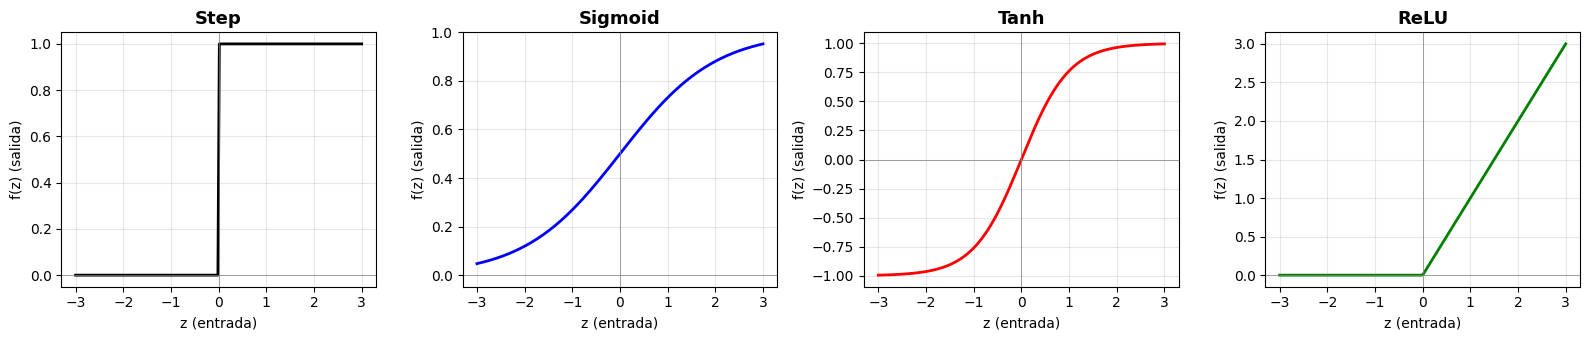

Entrada z = -1.5
  Step:    0    → neurona APAGADA
  Sigmoid: 0.182 → activación baja (casi apagada)
  Tanh:    -0.905 → activación negativa
  ReLU:    0.000  → neurona APAGADA (todo negativo se vuelve 0)

Entrada z = 2.0
  Step:    1    → neurona ENCENDIDA
  Sigmoid: 0.881 → activación alta
  Tanh:    0.964  → activación alta
  ReLU:    2.0   → pasa el valor directamente


In [18]:
# Visualización de las funciones de activación
z = np.linspace(-3, 3, 200)

# Definir las funciones
step    = np.where(z >= 0, 1, 0)
sigmoid = 1 / (1 + np.exp(-z))
tanh    = np.tanh(z)
relu    = np.maximum(0, z)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

for ax, func, name, color in zip(axes,
    [step, sigmoid, tanh, relu],
    ['Step', 'Sigmoid', 'Tanh', 'ReLU'],
    ['black', 'blue', 'red', 'green']):
    ax.plot(z, func, color=color, linewidth=2)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('z (entrada)')
    ax.set_ylabel('f(z) (salida)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Ejemplo: ¿qué pasa con un valor de entrada?
ejemplo = -1.5
print(f'Entrada z = {ejemplo}')
print(f'  Step:    {1 if ejemplo >= 0 else 0}    → neurona APAGADA')
print(f'  Sigmoid: {1/(1+np.exp(-ejemplo)):.3f} → activación baja (casi apagada)')
print(f'  Tanh:    {np.tanh(ejemplo):.3f} → activación negativa')
print(f'  ReLU:    {max(0, ejemplo):.3f}  → neurona APAGADA (todo negativo se vuelve 0)')

ejemplo2 = 2.0
print(f'\nEntrada z = {ejemplo2}')
print(f'  Step:    {1 if ejemplo2 >= 0 else 0}    → neurona ENCENDIDA')
print(f'  Sigmoid: {1/(1+np.exp(-ejemplo2)):.3f} → activación alta')
print(f'  Tanh:    {np.tanh(ejemplo2):.3f}  → activación alta')
print(f'  ReLU:    {max(0, ejemplo2):.1f}   → pasa el valor directamente')


In [19]:
mlp = MLPClassifier(hidden_layer_sizes=(100,50), activation='relu', solver='adam', learning_rate_init=0.01, max_iter=1000)
mlp.fit(X_train, y_train)

/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


MLPClassifier(hidden_layer_sizes=(100, 50), learning_rate_init=0.01,
              max_iter=1000)

In [20]:
y_pred_mlp = mlp.predict(X_test)
print(f"MLP Neural Net Accuracy: {accuracy_score(y_test, y_pred_mlp):.3f}")

MLP Neural Net Accuracy: 0.926


/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


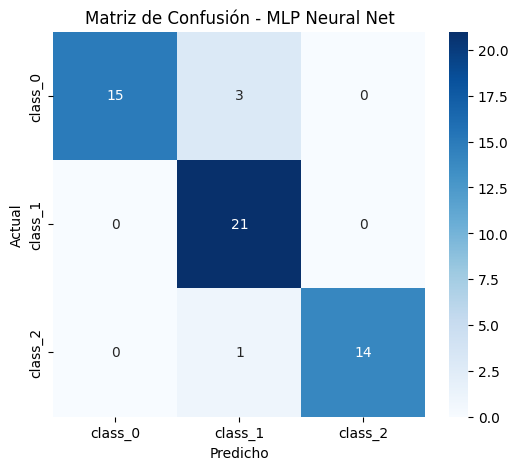

              precision    recall  f1-score   support

     class_0       1.00      0.83      0.91        18
     class_1       0.84      1.00      0.91        21
     class_2       1.00      0.93      0.97        15

    accuracy                           0.93        54
   macro avg       0.95      0.92      0.93        54
weighted avg       0.94      0.93      0.93        54



In [21]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_mlp, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names
)
plt.title("Matriz de Confusión - MLP Neural Net")
plt.xlabel('Predicho')
plt.ylabel('Actual')
plt.show()
print(classification_report(y_test, y_pred_mlp, target_names=class_names))

## ¿Por qué tiene tan mal precisión? ¿cómo lo podemos mejorar? Se me olvidó algo importante 🤦‍♂️

In [22]:
X_train

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
12,13.75,1.73,2.41,16.0,89.0,2.60,2.76,0.29,1.81,5.60,1.15,2.90,1320.0
30,13.73,1.50,2.70,22.5,101.0,3.00,3.25,0.29,2.38,5.70,1.19,2.71,1285.0
36,13.28,1.64,2.84,15.5,110.0,2.60,2.68,0.34,1.36,4.60,1.09,2.78,880.0
31,13.58,1.66,2.36,19.1,106.0,2.86,3.19,0.22,1.95,6.90,1.09,2.88,1515.0
120,11.45,2.40,2.42,20.0,96.0,2.90,2.79,0.32,1.83,3.25,0.80,3.39,625.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
168,13.58,2.58,2.69,24.5,105.0,1.55,0.84,0.39,1.54,8.66,0.74,1.80,750.0
114,12.08,1.39,2.50,22.5,84.0,2.56,2.29,0.43,1.04,2.90,0.93,3.19,385.0
152,13.11,1.90,2.75,25.5,116.0,2.20,1.28,0.26,1.56,7.10,0.61,1.33,425.0
136,12.25,4.72,2.54,21.0,89.0,1.38,0.47,0.53,0.80,3.85,0.75,1.27,720.0


Estandarizar las entradas ayuda a que todas las características “hablen el mismo idioma”, garantizando que cada una influya de forma proporcional en los gradientes y que el algoritmo de optimización converja de manera estable y eficiente.

MLP Neural Net Accuracy: 0.963


/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encoun

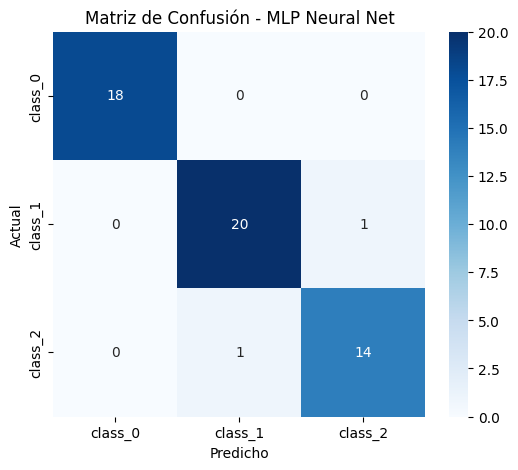

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       0.95      0.95      0.95        21
     class_2       0.93      0.93      0.93        15

    accuracy                           0.96        54
   macro avg       0.96      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54



In [23]:
# Escalar datos para MLP
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Definir MLP con parámetros optimizados
mlp = MLPClassifier(hidden_layer_sizes=(100,50), activation='relu', solver='adam', learning_rate_init=0.01, max_iter=1000)
mlp.fit(X_train_scaled, y_train)
# Evaluación de MLP
y_pred_mlp = mlp.predict(X_test_scaled)
acc_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"MLP Neural Net Accuracy: {acc_mlp:.3f}")
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_mlp,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Matriz de Confusión - MLP Neural Net")
plt.xlabel('Predicho')
plt.ylabel('Actual')
plt.show()
print(classification_report(y_test, y_pred_mlp, target_names=class_names))

### Comparación de Modelos de Clasificación

Comparemos el rendimiento de todos los modelos entrenados en una sola visualización.


/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


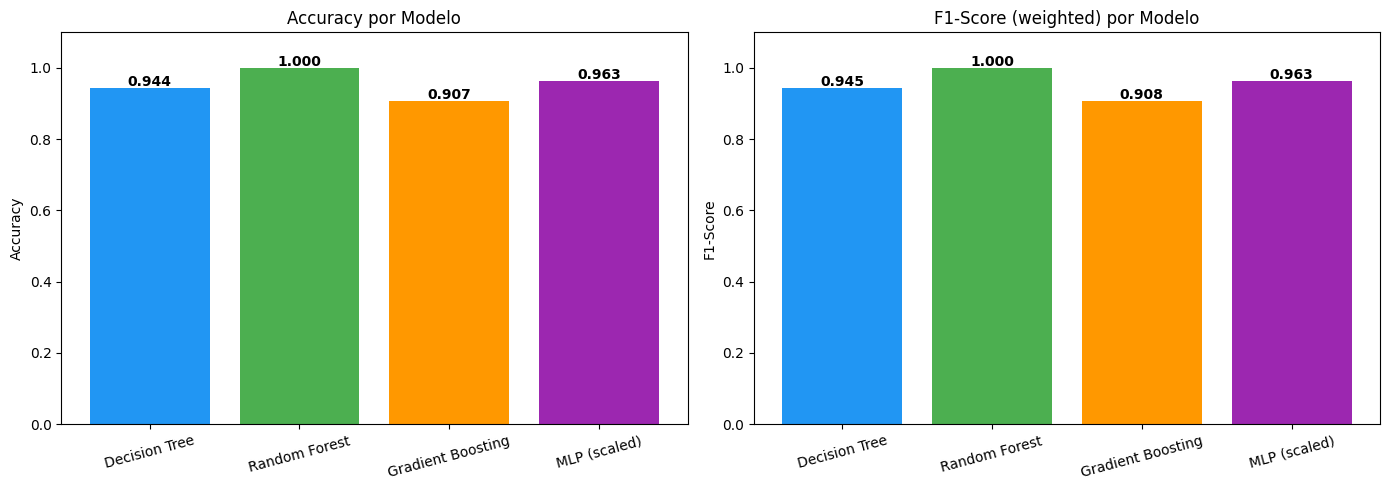

In [24]:
# Comparación de modelos de clasificación
from sklearn.metrics import f1_score

# Recopilar predicciones de todos los modelos
modelos_clf = ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'MLP (scaled)']

y_pred_dt_clf = dt.predict(X_test)
y_pred_rf_clf = rf.predict(X_test)
y_pred_gb_clf = gb.predict(X_test)
y_pred_mlp_clf = mlp.predict(X_test_scaled)

accuracies = [
    accuracy_score(y_test, y_pred_dt_clf),
    accuracy_score(y_test, y_pred_rf_clf),
    accuracy_score(y_test, y_pred_gb_clf),
    accuracy_score(y_test, y_pred_mlp_clf)
]

f1_scores = [
    f1_score(y_test, y_pred_dt_clf, average='weighted'),
    f1_score(y_test, y_pred_rf_clf, average='weighted'),
    f1_score(y_test, y_pred_gb_clf, average='weighted'),
    f1_score(y_test, y_pred_mlp_clf, average='weighted')
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars1 = ax1.bar(modelos_clf, accuracies, color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])
for bar, val in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.3f}', ha='center', fontweight='bold')
ax1.set_title('Accuracy por Modelo')
ax1.set_ylim(0, 1.1)
ax1.set_ylabel('Accuracy')
ax1.tick_params(axis='x', rotation=15)

bars2 = ax2.bar(modelos_clf, f1_scores, color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])
for bar, val in zip(bars2, f1_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.3f}', ha='center', fontweight='bold')
ax2.set_title('F1-Score (weighted) por Modelo')
ax2.set_ylim(0, 1.1)
ax2.set_ylabel('F1-Score')
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


# Regresiones

### Dataset: California Housing

Dataset de viviendas en California basado en el censo de 1990. Cada fila representa un **bloque de viviendas** (grupo de casas cercanas).

| Variable | Descripción |
|----------|-------------|
| MedInc | Ingreso mediano del bloque (en decenas de miles de dólares) |
| HouseAge | Edad mediana de las viviendas (años) |
| AveRooms | Promedio de habitaciones por vivienda |
| AveBedrms | Promedio de dormitorios por vivienda |
| Population | Población del bloque |
| AveOccup | Promedio de ocupantes por vivienda |
| Latitude | Latitud geográfica |
| Longitude | Longitud geográfica |
| **MedHouseVal** | **Valor mediano de la vivienda (en $100,000s) - TARGET** |

- **20,640 muestras** con 8 características
- Problema de **regresión**: predecir el precio mediano de viviendas


In [25]:
# Cargar California Housing dataset
# 8 características de bloques de vivienda y target = mediana de precios
# Documentación: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html

data = fetch_california_housing(as_frame=True)
df = data.frame.copy()
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']
feature_names = X.columns

# Dividir en train/test (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Escalar características
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [26]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


Dimensiones: (20640, 9)

Estadísticas descriptivas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


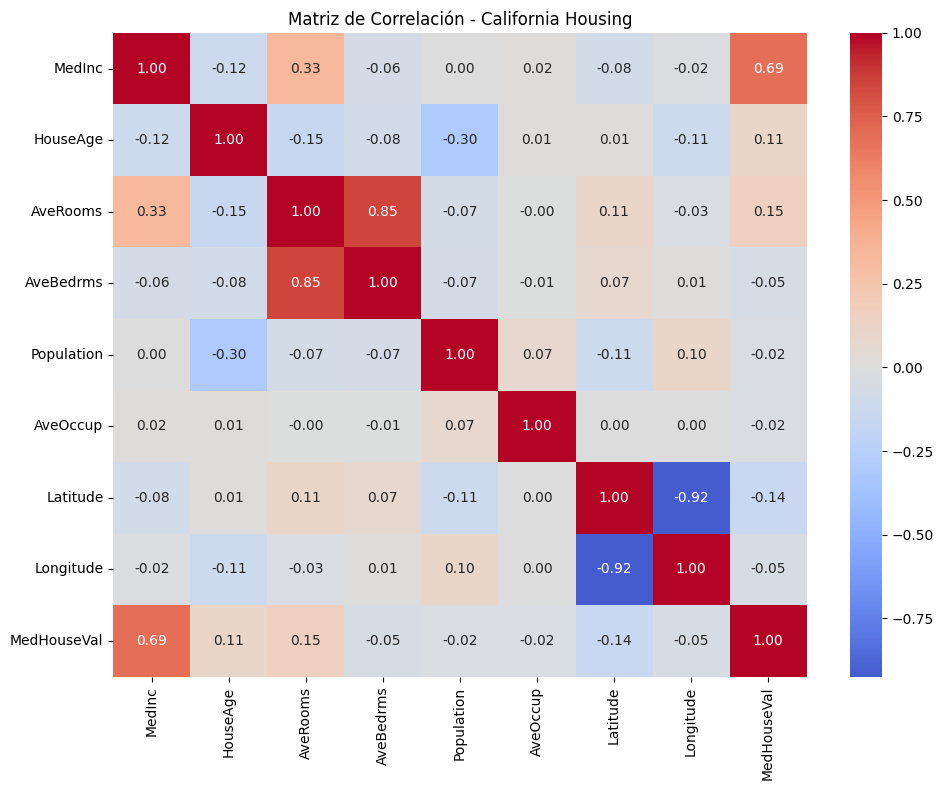

In [27]:
# Análisis exploratorio - California Housing
print(f'Dimensiones: {df.shape}')
print(f'\nEstadísticas descriptivas:')
display(df.describe().round(2))

# Heatmap de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación - California Housing')
plt.tight_layout()
plt.show()


### Decision Tree Regressor

- Árbol que particiona el espacio de características para predecir valores continuos.
- Hiperparámetros:
  * max_depth: Profundidad máxima del árbol.
  * min_samples_split: Muestras mínimas para dividir.
  * min_samples_leaf: Muestras mínimas en hojas.
- Pre-poda con max_depth para evitar overfitting.

- El valor que se predice es el valor promedio de todos los registros en la hoja o nodo resultante. 

Documentación:
https://scikit-learn.org/stable/modules/tree.html#regression

In [28]:
dt_reg = DecisionTreeRegressor(max_depth=6, random_state=42)
dt_reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=6, random_state=42)

In [29]:
y_pred_dt = dt_reg.predict(X_test)
MSE_DT = mean_squared_error(y_test, y_pred_dt)
R2_DT = r2_score(y_test, y_pred_dt)
print(f"Decision Tree MSE: {mean_squared_error(y_test, y_pred_dt):.3f}")
print(f"Decision Tree R2: {r2_score(y_test, y_pred_dt):.3f}")

Decision Tree MSE: 0.478
Decision Tree R2: 0.636


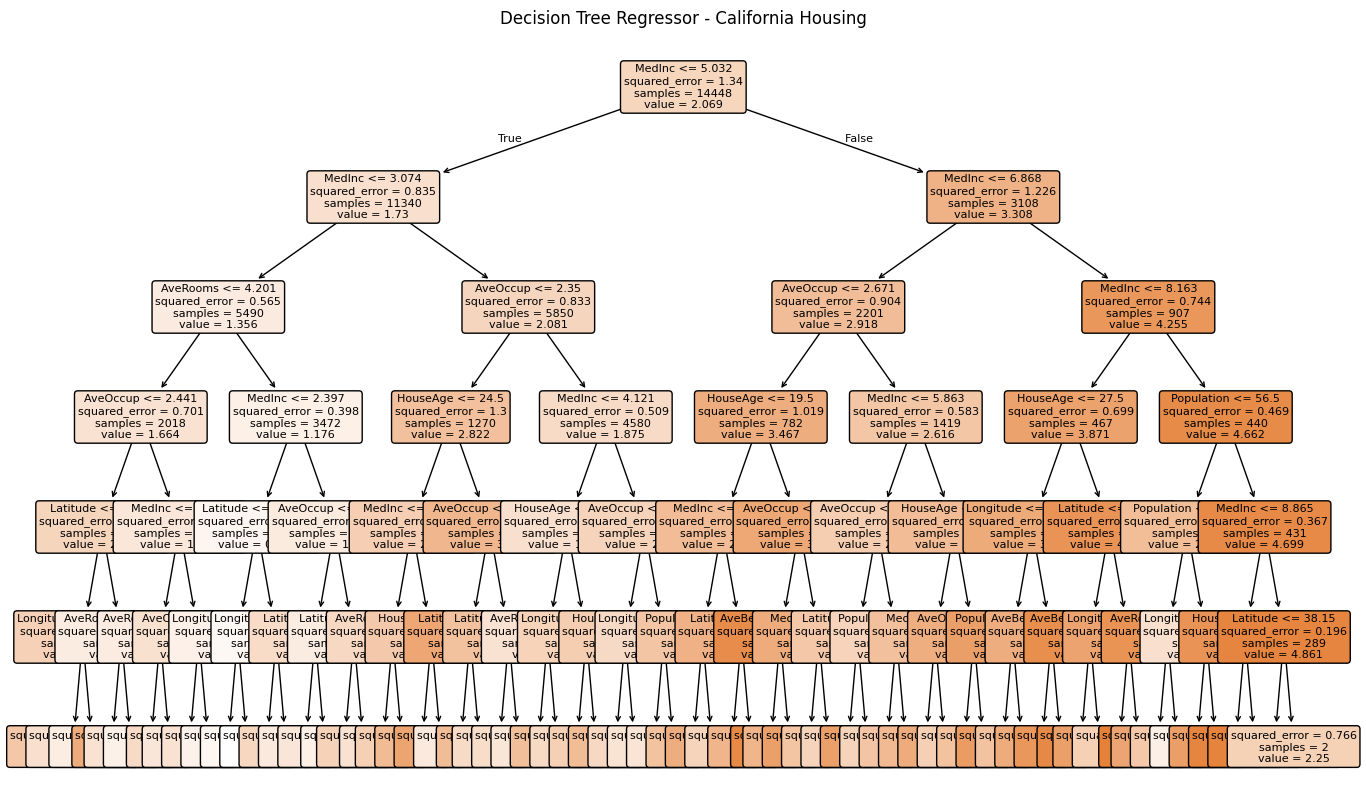

In [30]:
a = plt.figure(figsize=(16,10))
plot_tree(
    dt_reg,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Regressor - California Housing")
plt.show()

### Random Forest Regressor

- **Ensamble por Bagging**: Entrena múltiples árboles de decisión en paralelo, cada uno con una muestra aleatoria (bootstrap) de los datos.
- **Predicción**: El resultado final es el **promedio** de las predicciones de todos los árboles (a diferencia de clasificación donde se usa votación por mayoría).
- **Ventajas**: Reduce la varianza del modelo sin aumentar mucho el sesgo. Más robusto que un solo árbol.
- Hiperparámetros clave:
  * `n_estimators`: Número de árboles en el bosque (más árboles = más estable, pero más lento).
  * `max_depth`: Profundidad máxima de cada árbol.
  * `max_features`: Número de características consideradas en cada split (introduce diversidad entre árboles).

Documentación:
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html


In [31]:
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
rf_reg.fit(X_train, y_train)

RandomForestRegressor(max_depth=8, random_state=42)

In [32]:
y_pred_rf = rf_reg.predict(X_test)
MSE_RF = mean_squared_error(y_test, y_pred_rf)
R2_RF = r2_score(y_test, y_pred_rf)
print(f"Random Forest MSE: {mean_squared_error(y_test, y_pred_rf):.3f}")
print(f"Random Forest R2: {r2_score(y_test, y_pred_rf):.3f}")

Random Forest MSE: 0.337
Random Forest R2: 0.744


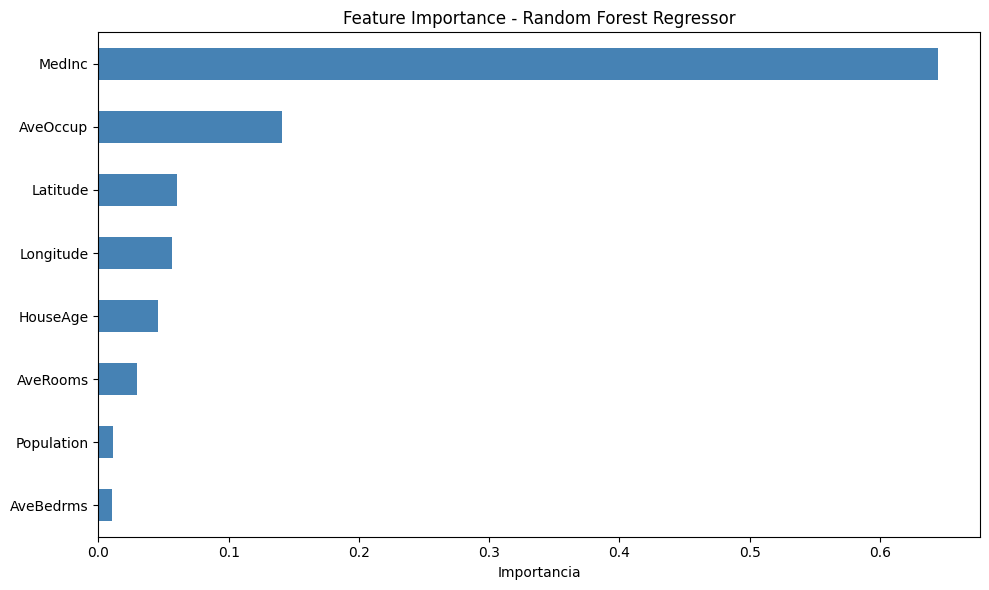

In [33]:
# Feature Importance - Random Forest Regressor
fi_rf = pd.Series(rf_reg.feature_importances_, index=feature_names).sort_values()
plt.figure(figsize=(10, 6))
fi_rf.plot(kind='barh', color='steelblue')
plt.title('Feature Importance - Random Forest Regressor')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()


### Gradient Boosting Regressor

- **Ensamble Secuencial**: A diferencia de Random Forest (paralelo), Gradient Boosting entrena árboles **uno tras otro**.
- **Cómo funciona**: Cada nuevo árbol se entrena para predecir el **error residual** (la diferencia entre la predicción actual y el valor real). La predicción final es la suma ponderada de todos los árboles.
- **Analogía**: Es como un estudiante que revisa sus errores en cada examen y se enfoca en mejorar exactamente donde falló.
- Hiperparámetros clave:
  * `learning_rate`: Cuánto aporta cada árbol nuevo (valores pequeños como 0.01-0.1 funcionan mejor pero necesitan más árboles).
  * `n_estimators`: Número de árboles secuenciales.
  * `max_depth`: Profundidad de cada árbol (usualmente 3-5, árboles más pequeños que en RF).
- **Trade-off**: `learning_rate` bajo + muchos `n_estimators` = mejor resultado pero más tiempo de entrenamiento.

Documentación:
https://scikit-learn.org/stable/modules/ensemble.html#gradient-boosting


In [34]:
gb_reg = GradientBoostingRegressor(
    n_estimators=150, learning_rate=0.05, max_depth=4, random_state=42
)
gb_reg.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=4, n_estimators=150,
                          random_state=42)

In [35]:
y_pred_gb = gb_reg.predict(X_test)
MSE_GB = mean_squared_error(y_test, y_pred_gb)
R2_GB = r2_score(y_test, y_pred_gb)
print(f"Gradient Boosting MSE: {mean_squared_error(y_test, y_pred_gb):.3f}")
print(f"Gradient Boosting R2: {r2_score(y_test, y_pred_gb):.3f}")

Gradient Boosting MSE: 0.268
Gradient Boosting R2: 0.796


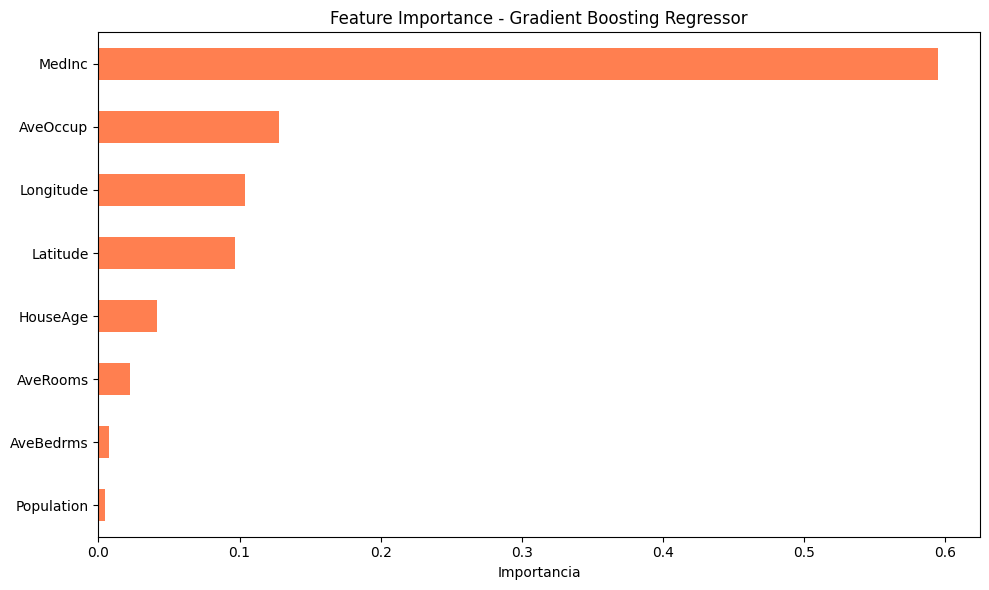

In [36]:
# Feature Importance - Gradient Boosting Regressor
fi_gb = pd.Series(gb_reg.feature_importances_, index=feature_names).sort_values()
plt.figure(figsize=(10, 6))
fi_gb.plot(kind='barh', color='coral')
plt.title('Feature Importance - Gradient Boosting Regressor')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()


### MLP Regressor

MLPRegressor:
- Red neuronal para regresión continua.
- Hiperparámetros:
  * hidden_layer_sizes: neuronas en capas ocultas.
  * activation: función de activación.
  * solver: optimizador.
  * learning_rate_init: tasa de aprendizaje.
  * alpha: regularización L2.
  * early_stopping: detiene si no hay mejora.

Documentación:
https://scikit-learn.org/stable/modules/neural_networks_supervised.html

In [37]:
mlp_reg = MLPRegressor(
    hidden_layer_sizes=(100,50), activation='relu', solver='adam',
    learning_rate_init=0.01, alpha=0.001, max_iter=2000,
    early_stopping=True, verbose=True
)
mlp_reg.fit(X_train_scaled, y_train)

Iteration 1, loss = 0.40191713
Validation score: 0.675895
Iteration 2, loss = 0.19998373
Validation score: 0.702996
Iteration 3, loss = 0.18680195
Validation score: 0.722395
Iteration 4, loss = 0.17898333
Validation score: 0.736158
Iteration 5, loss = 0.16777384
Validation score: 0.752529
Iteration 6, loss = 0.16834395
Validation score: 0.741020
Iteration 7, loss = 0.16065719
Validation score: 0.747243
Iteration 8, loss = 0.16357920
Validation score: 0.732512


/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encoun

Iteration 9, loss = 0.16698440
Validation score: 0.709095
Iteration 10, loss = 0.16305206
Validation score: 0.755811
Iteration 11, loss = 0.15245208
Validation score: 0.758067
Iteration 12, loss = 0.15629667
Validation score: 0.772083
Iteration 13, loss = 0.15380069
Validation score: 0.767556
Iteration 14, loss = 0.15197320
Validation score: 0.764730
Iteration 15, loss = 0.15062032
Validation score: 0.776840
Iteration 16, loss = 0.14749065
Validation score: 0.740709
Iteration 17, loss = 0.15334074
Validation score: 0.770718
Iteration 18, loss = 0.14410997
Validation score: 0.789999
Iteration 19, loss = 0.14069245
Validation score: 0.778756
Iteration 20, loss = 0.14116059
Validation score: 0.688158


/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encoun

Iteration 21, loss = 0.18192693
Validation score: 0.778806
Iteration 22, loss = 0.15323842
Validation score: 0.770384
Iteration 23, loss = 0.14499321
Validation score: 0.773690
Iteration 24, loss = 0.14268561
Validation score: 0.792796
Iteration 25, loss = 0.14288361
Validation score: 0.792624
Iteration 26, loss = 0.14077490
Validation score: 0.791309
Iteration 27, loss = 0.13421007
Validation score: 0.783823
Iteration 28, loss = 0.13905126
Validation score: 0.735339
Iteration 29, loss = 0.14798493
Validation score: 0.796699
Iteration 30, loss = 0.13512519
Validation score: 0.793591
Iteration 31, loss = 0.13725684
Validation score: 0.792166
Iteration 32, loss = 0.13241963
Validation score: 0.790091
Iteration 33, loss = 0.13377121
Validation score: 0.784375


/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encoun

Iteration 34, loss = 0.13715111
Validation score: 0.800893
Iteration 35, loss = 0.13067403
Validation score: 0.781900
Iteration 36, loss = 0.13100343
Validation score: 0.771642
Iteration 37, loss = 0.13098430
Validation score: 0.757926
Iteration 38, loss = 0.14196827
Validation score: 0.772542
Iteration 39, loss = 0.13746951
Validation score: 0.782771
Iteration 40, loss = 0.13029207
Validation score: 0.786054
Iteration 41, loss = 0.13563982
Validation score: 0.768716
Iteration 42, loss = 0.14369606
Validation score: 0.619193
Iteration 43, loss = 0.15716599
Validation score: 0.789288
Iteration 44, loss = 0.13487331
Validation score: 0.790410
Iteration 45, loss = 0.13163350
Validation score: 0.783812
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encoun

MLPRegressor(alpha=0.001, early_stopping=True, hidden_layer_sizes=(100, 50),
             learning_rate_init=0.01, max_iter=2000, verbose=True)

In [38]:
y_pred_mlp = mlp_reg.predict(X_test_scaled)
MSE_MLP = mean_squared_error(y_test, y_pred_mlp)
R2_MLP = r2_score(y_test, y_pred_mlp)
print(f"MLP Regressor MSE: {mean_squared_error(y_test, y_pred_mlp):.3f}")
print(f"MLP Regressor R2: {r2_score(y_test, y_pred_mlp):.3f}")

MLP Regressor MSE: 0.264
MLP Regressor R2: 0.799


/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


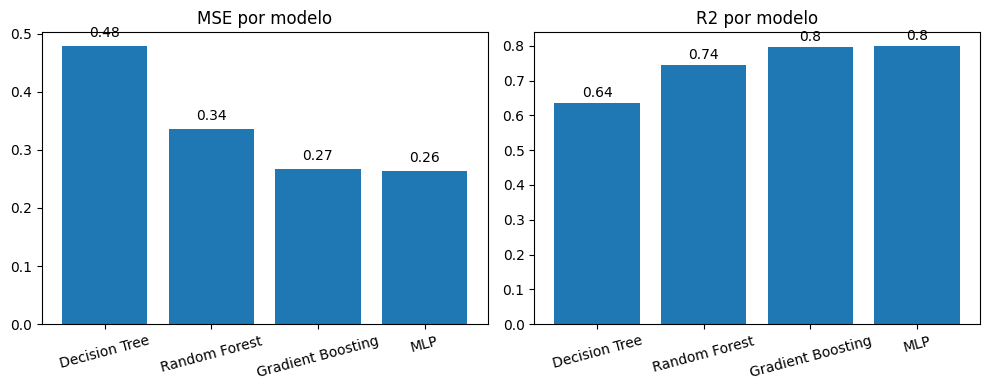

In [39]:
models = ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'MLP']
mse = [MSE_DT,
      MSE_RF,
      MSE_GB,
      MSE_MLP]
r2 = [R2_DT,
      R2_RF,
      R2_GB,
      R2_MLP]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.bar(models, mse)
for i, v in enumerate(mse):
    plt.text(i, v + 0.01, str(round(v, 2)), ha='center', va='bottom')
plt.title('MSE por modelo')
plt.xticks(rotation=15)
plt.subplot(1,2,2)
plt.bar(models, r2)
for i, v in enumerate(r2):
    plt.text(i, v + 0.01, str(round(v, 2)), ha='center', va='bottom')
plt.title('R2 por modelo')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Interpretación de los resultados

- **MSE (Mean Squared Error)**: Menor es mejor. Mide el error promedio al cuadrado.
- **R² (Coeficiente de Determinación)**: Más cercano a 1 es mejor. Indica qué proporción de la varianza es explicada por el modelo.
- Los modelos ensamblados (Random Forest, Gradient Boosting) generalmente superan al árbol individual porque reducen la varianza (RF) o corrigen errores iterativamente (GB).
- El MLP puede competir con los ensamblados si los datos están bien escalados y la arquitectura es adecuada.


# Deep Learning

## Convolutional Neural Networks (CNN)

- **¿Qué son?**  
  Redes diseñadas para datos en cuadrícula (imágenes) que utilizan **convoluciones** para extraer características locales.

- **Capas principales:**  
  1. **Convolucionales:** filtros (kernels) que detectan patrones (bordes, texturas).  
  2. **ReLU:** introduce no linealidad (`f(x)=max(0,x)`).  
  3. **Pooling:** reduce resolución espacial (p. ej. max‑pooling 2×2), aportando invarianza.

- **Ventajas:**  
    - **Compartición de pesos:** mismos filtros en toda la imagen.  
    - **Menos parámetros** que un MLP equivalente.  
    - **Robustez** a traslaciones y distorsiones pequeñas.

- **Uso habitual:**  
Clasificación de imágenes, detección de objetos, segmentación semántica, etc.


In [41]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [42]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
## length of the train 
print(len(x_train), len(y_train))
print(len(x_test), len(y_test))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
60000 60000
10000 10000


### Dataset MNIST

MNIST (Modified National Institute of Standards and Technology) es uno de los datasets más famosos en Machine Learning:
- **70,000 imágenes** de dígitos escritos a mano (0-9)
- **60,000** para entrenamiento y **10,000** para test
- Cada imagen es de **28 x 28 píxeles** en escala de grises
- **10 clases** (dígitos del 0 al 9)
- Los valores de cada píxel van de 0 (negro) a 255 (blanco)


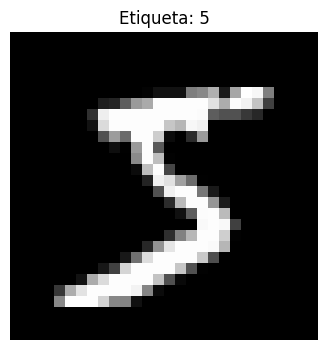

In [43]:
plt.figure(figsize=(4, 4))
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Etiqueta: {y_train[0]}")
plt.axis('off')
plt.show()

In [44]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

### Expandir dimensión de canal (batch, alto, ancho, canales)

- -1: Calcula automáticamente el tamaño del primer eje (número de muestras).
- 28, 28: Mantiene las dimensiones originales de las imágenes (28x28 píxeles).
- 1: Agrega un canal adicional para representar imágenes en escala de grises (1 canal). Esto es necesario porque las CNNs esperan datos con canales, como imágenes RGB (3 canales) o escala de grises (1 canal).

In [45]:
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test  = x_test .reshape(-1, 28, 28, 1).astype('float32') / 255.0



One hot encoder para Y

0 = [1,0,0,0,0,0,0,0,0,0]
1 = [0,1,0,0,0,0,0,0,0,0]
2 = [0,0,1,0,0,0,0,0,0,0]
.
.
.
9 = [0,0,0,0,0,0,0,0,0,1]


In [46]:
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

In [47]:
x_train[0]

array([[[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        

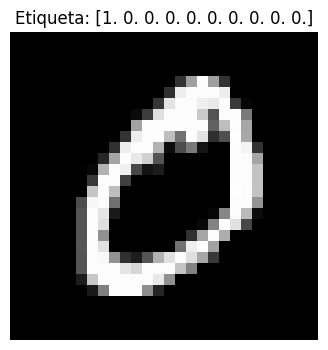

In [48]:
plt.figure(figsize=(4, 4))
plt.imshow(x_train[1], cmap='gray')
plt.title(f"Etiqueta: {y_train[1]}")
plt.axis('off')
plt.show()

## Definir la arquitectura CNN


In [49]:
model = models.Sequential([
    # Capa convolucional: extrae patrones locales
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    # Pooling: reduce dimensionalidad
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    # Aplanar para pasar a capas densas
    layers.Flatten(),
    # Capa oculta totalmente conectada
    layers.Dense(64, activation='relu'),
    # Capa de salida con softmax para 10 clases
    layers.Dense(10, activation='softmax')
])

/Users/hectorfabioocampoarbelaez/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
# Resumen de la arquitectura del modelo
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

## Compilar el modelo

In [51]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Entrenando el modelo

 - Epoch: cuantas pasadas completas por el conjunto completo
 - Batch size: número de muestras procesadas antes de actualizar el modelo
 - validation_split: porcentaje de datos para validación

In [52]:
history = model.fit(
    x_train, y_train,
    epochs=10,              # número de pasadas sobre el dataset
    batch_size=128,         # tamaño de lote
    validation_split=0.1,   # 10% de validación
)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8332 - loss: 0.5646 - val_accuracy: 0.9813 - val_loss: 0.0709
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9756 - loss: 0.0765 - val_accuracy: 0.9870 - val_loss: 0.0486
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9852 - loss: 0.0492 - val_accuracy: 0.9887 - val_loss: 0.0459
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9879 - loss: 0.0387 - val_accuracy: 0.9888 - val_loss: 0.0387
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9913 - loss: 0.0290 - val_accuracy: 0.9895 - val_loss: 0.0392
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9916 - loss: 0.0258 - val_accuracy: 0.9907 - val_loss: 0.0341
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9945 - loss: 0.0182 - val_accuracy: 0.9903 - val_loss: 0.0323
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9948 - loss: 0.0159 - val_accuracy: 0.

### Curvas de Entrenamiento

Las curvas de entrenamiento nos permiten visualizar cómo evoluciona el modelo durante el entrenamiento:
- Si la **accuracy de entrenamiento** sube pero la de **validación se estanca o baja**, hay **overfitting**.
- Si **ambas curvas suben juntas**, el modelo está aprendiendo correctamente.
- Si el **loss sigue bajando**, el modelo aún podría beneficiarse de más epochs.


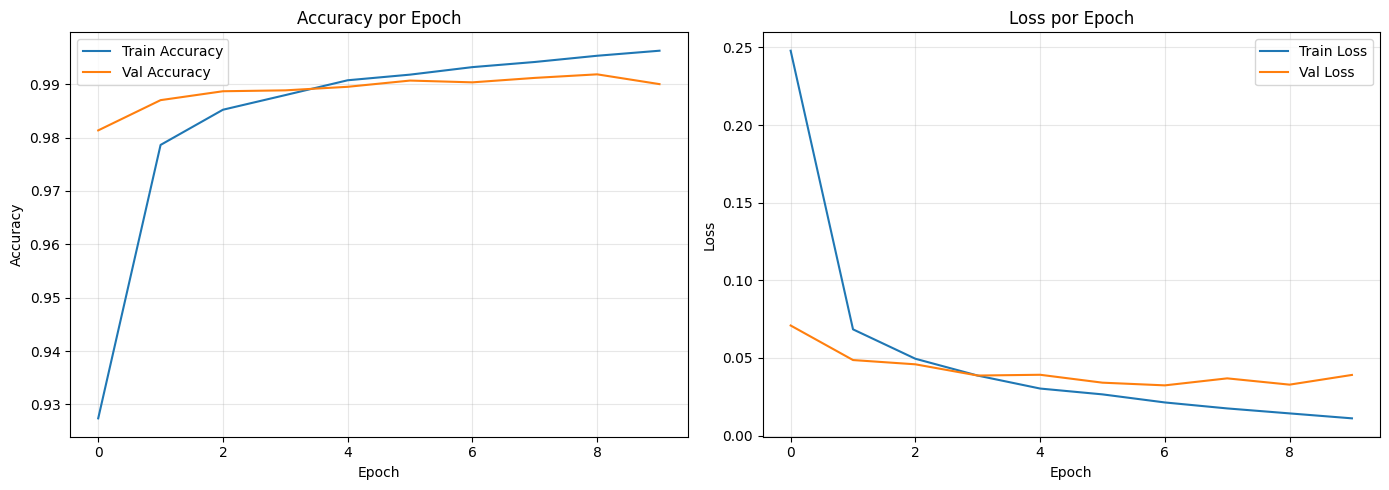

In [53]:
# Visualización de las curvas de entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Accuracy por Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Loss por Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Validar el modelo

In [54]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 889us/step - accuracy: 0.9877 - loss: 0.0422
Test accuracy: 0.990


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step


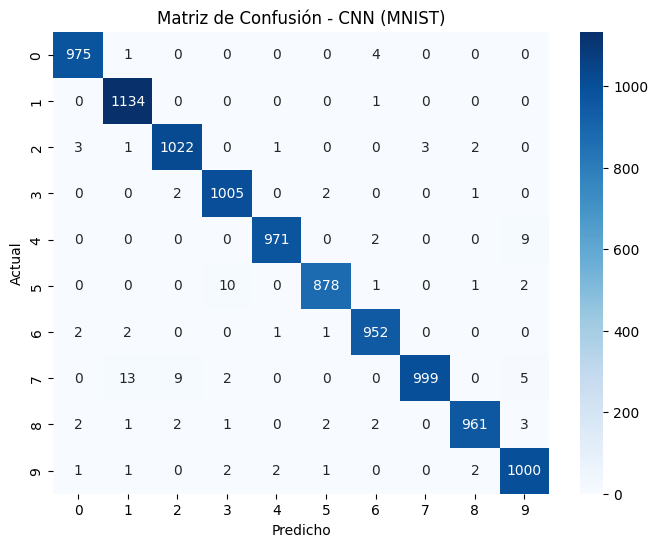

In [55]:
# Matriz de confusión del CNN
y_pred_cnn = model.predict(x_test)
y_pred_classes = np.argmax(y_pred_cnn, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm_cnn = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Matriz de Confusión - CNN (MNIST)')
plt.xlabel('Predicho')
plt.ylabel('Actual')
plt.show()


## Prueba propia
escribe tu propio numero y mira si lo clasifica bien
https://sketch.io/sketchpad/

recuerda hacerlo en 28x28 pixeles

In [56]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Cargar la imagen
image_path = "7test.png"  # Cambia esto por la ruta de tu imagen
img = Image.open(image_path).convert('L')  # Convertir a escala de grises

# Preprocesar la imagen
img_resized = img.resize((28, 28))  # Redimensionar a 28x28 píxeles
img_array = np.array(img_resized).astype('float32') / 255.0  # Normalizar entre 0 y 1
img_array = img_array.reshape(1, 28, 28, 1)  # Expandir dimensiones

# Realizar la predicción
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

# Mostrar la imagen y la predicción
plt.figure(figsize=(4, 4))
plt.imshow(img_resized, cmap='gray')
plt.title(f"Predicción: {predicted_class}")
plt.axis('off')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '7test.png'

## Reto Final: Predicción de Supervivencia en el Titanic

El dataset del Titanic contiene información de los pasajeros del famoso naufragio de 1912. Tu objetivo es construir un modelo que prediga si un pasajero sobrevivió o no.

### Descripción del Dataset:

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `survived` | int | **Variable objetivo.** 0 = No sobrevivió, 1 = Sobrevivió |
| `pclass` | int | Clase del boleto: 1 = Primera (lujo), 2 = Segunda, 3 = Tercera (más económica). Refleja el nivel socioeconómico |
| `sex` | str | Sexo del pasajero: male / female |
| `age` | float | Edad en años. Tiene valores nulos que debes manejar |
| `sibsp` | int | Número de hermanos o esposos a bordo del Titanic |
| `parch` | int | Número de padres o hijos a bordo del Titanic |
| `fare` | float | Tarifa pagada por el boleto (en libras esterlinas de 1912) |
| `embarked` | str | Puerto de embarque: C = Cherbourg (Francia), Q = Queenstown (Irlanda), S = Southampton (Inglaterra) |
| `class` | str | Igual que pclass pero en texto: First, Second, Third |
| `who` | str | Categoría: man, woman, child |
| `adult_male` | bool | True si es hombre adulto |
| `deck` | str | Cubierta de la cabina (A-G). Muchos valores nulos |
| `embark_town` | str | Nombre completo del puerto de embarque |
| `alive` | str | Igual que survived pero en texto: yes / no |
| `alone` | bool | True si viajaba sin familia (sibsp=0 y parch=0) |

**Nota:** Algunas columnas son redundantes (class/pclass, embark_town/embarked, alive/survived). Elige las que consideres más útiles y descarta las demás.

### Instrucciones:
1. Carga el dataset y realiza un análisis exploratorio
2. Limpia los datos (nulls, encoding de variables categóricas)
3. Divide en train/test (70/30)
4. Entrena al menos **3 modelos** de los vistos en clase
5. Recuerda **escalar** los datos antes de usar MLP
6. Compara los modelos con matriz de confusión y classification_report
7. Muestra el **feature importance** de al menos un modelo basado en árboles

### El Reto:
Al final hay **5 pasajeros misteriosos** cuyo destino no conoces. Usa tu mejor modelo para predecir si sobrevivieron o no. Los estudiantes con las predicciones más acertadas ganan.


In [79]:
import pandas as pd
import numpy as np

# Cargar el dataset del Titanic
df_titanic = pd.read_csv('titanic.csv')

print(f'Dataset: {len(df_titanic)} pasajeros')
df_titanic.head(10)


Dataset: 886 pasajeros


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [80]:
# Exploración inicial
print(f'Dimensiones: {df_titanic.shape}')
print(f'\nValores nulos:')
print(df_titanic.isnull().sum())
print(f'\nDistribución de supervivencia:')
print(df_titanic['survived'].value_counts())
df_titanic.describe()


Dimensiones: (886, 15)

Valores nulos:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           684
embark_town      2
alive            0
alone            0
dtype: int64

Distribución de supervivencia:
survived
0    547
1    339
Name: count, dtype: int64


,survived,pclass,age,sibsp,parch,fare
count,886.000000,886.000000,709.000000,886.000000,886.000000,886.000000
mean,0.382619,2.310384,29.687123,0.518059,0.378104,32.079467
std,0.486301,0.835406,14.477280,1.098129,0.801366,49.679454
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.000000,0.000000,0.000000,7.895800
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,30.923950
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [81]:
# Preparación de datos
# Seleccionar columnas relevantes
cols = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
df_work = df_titanic[cols].copy()

# Manejar valores nulos
# TODO: Completa la limpieza de datos
# Hint: age tiene muchos nulls
# Hint: embarked tiene pocos nulls


# Encoding de variables categóricas
# TODO: Convierte 'sex' y 'embarked' a valores numéricos
# Hint: pd.get_dummies() o map({'male': 0, 'female': 1})



In [82]:
# Separar X e y
# TODO: Define X (features) y y (target: survived)


# Train/Test split (70/30)
# TODO: Usa train_test_split con stratify=y


# Entrenar modelos (al menos 3)
# TODO: Entrena tus modelos aquí
# Recuerda: escalar los datos si usas MLP



In [ ]:
# Evaluación y comparación de modelos
# TODO: Muestra accuracy, confusion matrix y classification_report de cada modelo






## Los 5 Pasajeros Misteriosos

Estos son 5 pasajeros **reales** del Titanic que fueron separados del dataset antes del entrenamiento. Tu modelo nunca los ha visto.

Tu misión: **predecir si sobrevivieron o no** usando tu mejor modelo.

Recuerda aplicar el mismo preprocesamiento que usaste en el entrenamiento.

| Pasajero | Clase | Sexo | Edad | Hermanos/Esposos | Padres/Hijos | Tarifa | Embarque |
|----------|-------|------|------|------------------|--------------|--------|----------|
| A | 1ra | male | 22 | 0 | 0 | 135.63 | C |
| B | 2da | female | 24 | 2 | 3 | 18.75 | S |
| C | 3ra | male | 4 | 4 | 2 | 31.28 | S |
| D | 1ra | female | 63 | 1 | 0 | 77.96 | S |
| E | 3ra | male | 44 | 0 | 0 | 7.93 | S |


In [86]:
# Los 5 pasajeros misteriosos
# Estos datos fueron separados del dataset original antes de entregarlo
pasajeros_misterio = pd.DataFrame({
    'pclass':   [1,       2,        3,      1,        3],
    'sex':      ['male',  'female', 'male', 'female', 'male'],
    'age':      [22.0,    24.0,     4.0,    63.0,     44.0],
    'sibsp':    [0,       2,        4,      1,        0],
    'parch':    [0,       3,        2,      0,        0],
    'fare':     [135.63,  18.75,    31.28,  77.96,    7.93],
    'embarked': ['C',     'S',      'S',    'S',      'S']
}, index=['Pasajero A', 'Pasajero B', 'Pasajero C', 'Pasajero D', 'Pasajero E'])

print('Pasajeros Misteriosos:')
pasajeros_misterio


Pasajeros Misteriosos:


,pclass,sex,age,sibsp,parch,fare,embarked
Pasajero A,1,male,22.0,0,0,135.63,C
Pasajero B,2,female,24.0,2,3,18.75,S
Pasajero C,3,male,4.0,4,2,31.28,S
Pasajero D,1,female,63.0,1,0,77.96,S
Pasajero E,3,male,44.0,0,0,7.93,S


In [85]:
# TODO: Preprocesa los pasajeros misteriosos (mismo proceso que los datos de entrenamiento)
# TODO: Usa tu mejor modelo para predecir


# Escribe tus predicciones aquí:
# Pasajero A (hombre, 22 años, 1ra clase): Sobrevive? ___
# Pasajero B (mujer, 24 años, 2da clase):  Sobrevive? ___
# Pasajero C (niño, 4 años, 3ra clase):    Sobrevive? ___
# Pasajero D (mujer, 63 años, 1ra clase):  Sobrevive? ___
# Pasajero E (hombre, 44 años, 3ra clase): Sobrevive? ___
